In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime

In [2]:
# Set style for all visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

In [3]:
# Task 1: Load and Explore the Dataset
print("Loading the South Africa load shedding history dataset....")
try:
    df = pd.read_csv('../data/south_africa_load_shedding_history.csv')
    print("Dataset loaded successfully!")
except Exception as e:
    print(f"Error loading the dataset: {e}")
    exit()

Loading the South Africa load shedding history dataset....
Dataset loaded successfully!


In [4]:
# Display the first 5 rows of the dataset
print("\nFirst 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
          created_at  stage
0  9/7/2020 20:03:18      0
1  9/7/2020 14:00:22      2
2   9/7/2020 6:00:53      1
3  9/6/2020 18:16:14      0
4  9/6/2020 10:00:25      1


In [5]:
# Check the structure of the dataset
print("\nDataset information:")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nColumn data types:")
print(df.dtypes)


Dataset information:
Number of rows: 422
Number of columns: 2

Column data types:
created_at    object
stage          int64
dtype: object


In [6]:
# Check for missing values
print("\nMissing values in each columns:")
print(df.isnull().sum())


Missing values in each columns:
created_at    0
stage         0
dtype: int64


In [8]:
# Convert created_at to datetime format
print("\nConverting 'created_at' to datetime format..")
df['created_at'] = pd.to_datetime(df['created_at'])
print("Conversion completed!")


Converting 'created_at' to datetime format..
Conversion completed!


In [9]:
# Extract year, month, hour and day from created_at
df['year'] = df['created_at'].dt.year
df['month'] = df['created_at'].dt.month
df['day'] = df['created_at'].dt.day
df['hour'] = df['created_at'].dt.hour

print("\nDataset after preprocessing:")
print(df.head())



Dataset after preprocessing:
           created_at  stage  year  month  day  hour
0 2020-09-07 20:03:18      0  2020      9    7    20
1 2020-09-07 14:00:22      2  2020      9    7    14
2 2020-09-07 06:00:53      1  2020      9    7     6
3 2020-09-06 18:16:14      0  2020      9    6    18
4 2020-09-06 10:00:25      1  2020      9    6    10


In [10]:
# Task 2: Basic structure analysis
# Count occurrences of each stage
stage_counts = df['stage'].value_counts().sort_index()
print("\nCount of each load shedding stage:")
print(stage_counts)


Count of each load shedding stage:
stage
0    165
1    110
2    121
3     11
4     14
6      1
Name: count, dtype: int64


In [12]:
# Group by year and month, calculate average stage
monthly_avg = df.groupby(['year', 'month'])['stage'].mean().reset_index()
print("\nAverage load shedding stage by year and month:")
print(monthly_avg.head(10))


Average load shedding stage by year and month:
   year  month     stage
0  2015      1  1.500000
1  2015      2  0.931034
2  2015      3  1.000000
3  2015      4  0.971429
4  2015      5  0.779412
5  2015      6  0.857143
6  2015      7  0.750000
7  2015      8  0.833333
8  2015      9  0.500000
9  2018      6  0.666667


In [13]:
# Calculate avg by hour of day
hourly_avg = df.groupby('hour')['stage'].mean().reset_index()
print("\nAverage load shedding stage by hour of day:")
print(hourly_avg)


Average load shedding stage by hour of day:
    hour     stage
0      0  2.000000
1      5  0.888889
2      6  1.111111
3      7  1.526316
4      8  1.916667
5      9  1.793103
6     10  2.000000
7     11  1.000000
8     12  1.500000
9     13  2.500000
10    14  2.500000
11    15  1.400000
12    16  1.459459
13    17  1.350000
14    18  2.000000
15    19  0.300000
16    20  0.468750
17    21  0.157895
18    22  0.250000
19    23  0.562500


In [15]:
# Distribution of stages by year
yearly_stage_dist = pd.crosstab(df['year'], df['stage'])
print("\nAverage load shedding stage by year:")
print(yearly_stage_dist)


Average load shedding stage by year:
stage    0   1   2  3   4  6
year                        
2015   100  76  57  4   0  0
2018    14  13   8  0   0  0
2019    16   9  24  4  10  1
2020    35  12  32  3   4  0


In [16]:
# Task 3: Data Visualization
# Create a figure with subplots
plt.figure(figsize=(15, 20))

<Figure size 1500x2000 with 0 Axes>

<Figure size 1500x2000 with 0 Axes>

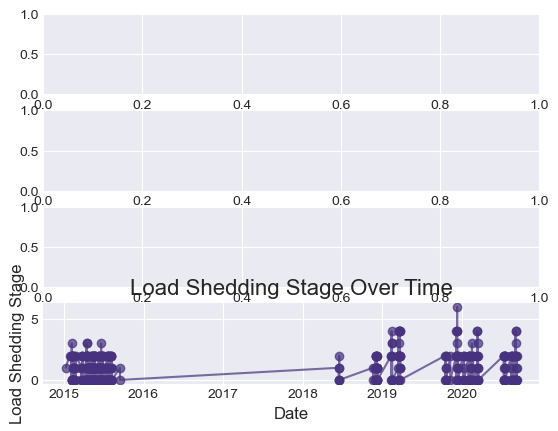

In [39]:
# 1. Line charts: Load shedding stages over time
plt.subplots(4, 1)
df.sort_values('created_at', inplace=True)
plt.plot(df['created_at'], df['stage'], marker='o', alpha=0.7)
plt.title('Load Shedding Stage Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Load Shedding Stage', fontsize=12)
plt.grid(True)
           

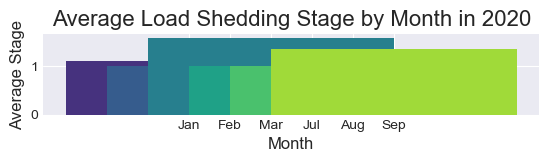

In [36]:
# 2. Bar Chart: Average stage by month 
plt.subplot(4, 1, 2)
latest_year = df['year'].max()
latest_year_data = df[df['year'] == latest_year]
monthly_avg_latest = latest_year_data.groupby('month')['stage'].mean()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_indicates = monthly_avg_latest.index.tolist()
month_labels = [months[i-1] for i in month_indicates]

plt.bar(month_labels, monthly_avg_latest.values, len(month_indicates), color=sns.color_palette("viridis")) 
plt.title(f'Average Load Shedding Stage by Month in {latest_year}', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Stage', fontsize=12)
plt.grid(True, axis='y')

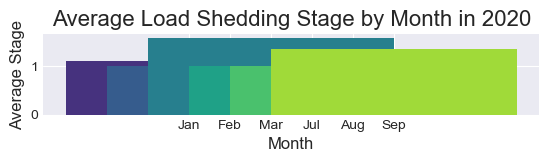

In [37]:
# 2. Bar Chart: Average stage by month 
plt.subplot(4, 1, 2)
latest_year = df['year'].max()
latest_year_data = df[df['year'] == latest_year]
monthly_avg_latest = latest_year_data.groupby('month')['stage'].mean()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_indicates = monthly_avg_latest.index.tolist()
month_labels = [months[i-1] for i in month_indicates]

plt.bar(month_labels, monthly_avg_latest.values, len(month_indicates), color=sns.color_palette("viridis"))
plt.title(f'Average Load Shedding Stage by Month in {latest_year}', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Stage', fontsize=12)
plt.grid(True, axis='y')

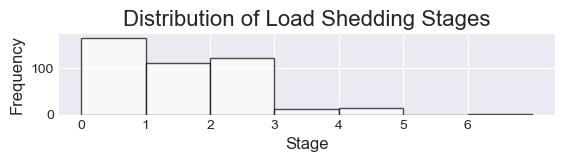

In [31]:
# 3. Histogram: Distribution fo load shedding stages
plt.subplot(4, 1, 3)
plt.hist(df['stage'], bins=range(0, 8), color='white', edgecolor='black', alpha=0.7)
plt.title('Distribution of Load Shedding Stages', fontsize=16)
plt.xlabel('Stage', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(range(0, 7))
plt.grid(True)

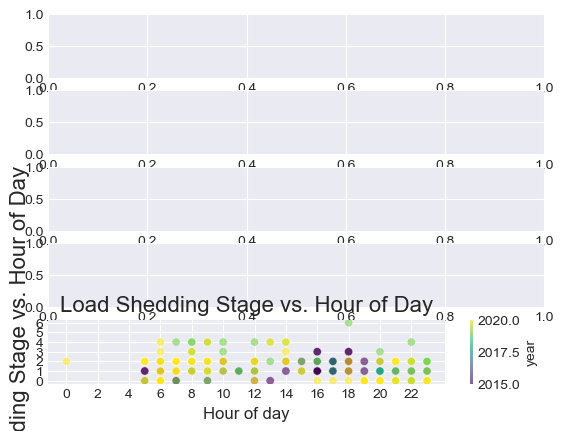

In [33]:
# 4. Scatter Plot
plt.subplots(5, 1)
scatter = plt.scatter(df['hour'], df['stage'], c=df['year'], cmap='viridis', alpha=0.6, edgecolors='w', linewidth=0.5)
plt.colorbar(scatter, label='year')
plt.title('Load Shedding Stage vs. Hour of Day', fontsize=16)
plt.xlabel('Hour of day', fontsize=12)
plt.ylabel('Load Shedding Stage vs. Hour of Day', fontsize=16)
plt.xticks(range(0, 24, 2))
plt.yticks(range(0, 7))
plt.grid(True)